In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('default')
sns.set()

Load Dataset

In [3]:
df = pd.read_csv("Flight_Price_Dataset_of_Bangladesh.csv")
print(df.head())
print(df.shape)

              Airline Source                           Source Name  \
0  Malaysian Airlines    CXB                   Cox's Bazar Airport   
1      Cathay Pacific    BZL                       Barisal Airport   
2     British Airways    ZYL  Osmani International Airport, Sylhet   
3  Singapore Airlines    RJH        Shah Makhdum Airport, Rajshahi   
4     British Airways    SPD                       Saidpur Airport   

  Destination                                   Destination Name  \
0         CCU  Netaji Subhas Chandra Bose International Airpo...   
1         CGP      Shah Amanat International Airport, Chittagong   
2         KUL                 Kuala Lumpur International Airport   
3         DAC      Hazrat Shahjalal International Airport, Dhaka   
4         YYZ              Toronto Pearson International Airport   

  Departure Date & Time  Arrival Date & Time  Duration (hrs) Stopovers  \
0   2025-11-17 06:25:00  2025-11-17 07:38:10        1.219526    Direct   
1   2025-03-16 00:17:0

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.994955,58899.556573,11448.238494,71030.316199,45.460579
std,4.094043,68840.614499,12124.344329,81769.199536,26.015657
min,0.500000,1600.975688,200.000000,1800.975688,1.000000
25%,1.003745,8856.316983,200.000000,9602.699787,23.000000
50%,2.644656,31615.996792,9450.940481,41307.544990,45.000000
75%,5.490104,85722.930389,17513.046160,103800.906963,68.000000
max,15.831719,449222.933770,73383.440066,558987.332444,90.000000


In [5]:
print(df.isnull().sum())

Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64


In [6]:
df = df.dropna()

Data Cleaning

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [12]:
print(df.columns)

Index(['airline', 'source', 'source_name', 'destination', 'destination_name',
       'departure_date_&_time', 'arrival_date_&_time', 'duration_(hrs)',
       'stopovers', 'aircraft_type', 'class', 'booking_source',
       'base_fare_(bdt)', 'tax_&_surcharge_(bdt)', 'total_fare_(bdt)',
       'seasonality', 'days_before_departure'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['airline', 'source', 'source_name', 'destination', 'destination_name',
       'departure_date_&_time', 'arrival_date_&_time', 'duration_(hrs)',
       'stopovers', 'aircraft_type', 'class', 'booking_source',
       'base_fare_(bdt)', 'tax_&_surcharge_(bdt)', 'total_fare_(bdt)',
       'seasonality', 'days_before_departure'],
      dtype='object')


In [15]:
for col in df.columns:
    print(col)

airline
source
source_name
destination
destination_name
departure_date_&_time
arrival_date_&_time
duration_(hrs)
stopovers
aircraft_type
class
booking_source
base_fare_(bdt)
tax_&_surcharge_(bdt)
total_fare_(bdt)
seasonality
days_before_departure


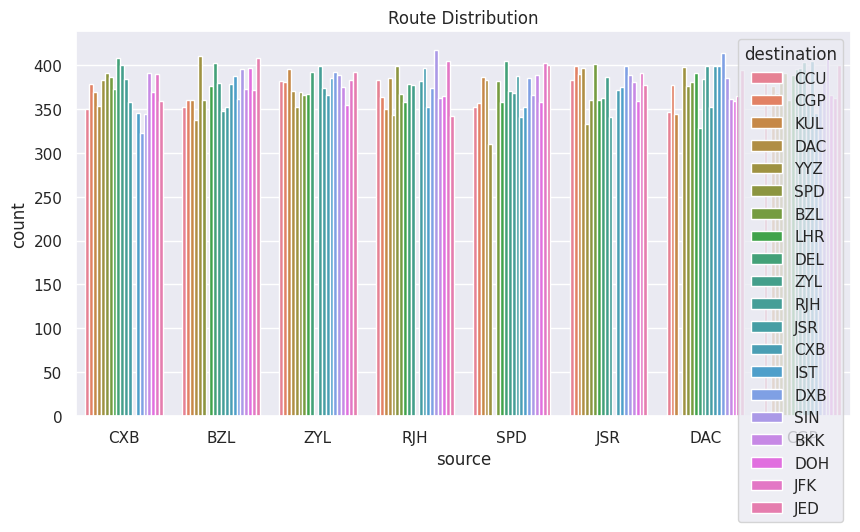

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='source', hue='destination', data=df)
plt.title("Route Distribution")
plt.show()

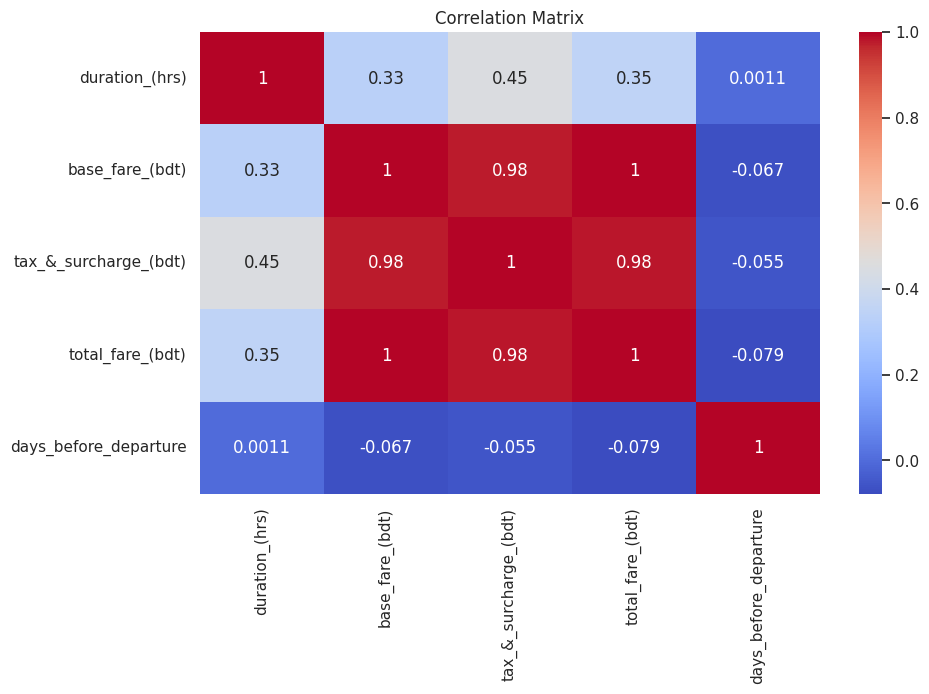

In [21]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Airline Market Distribution

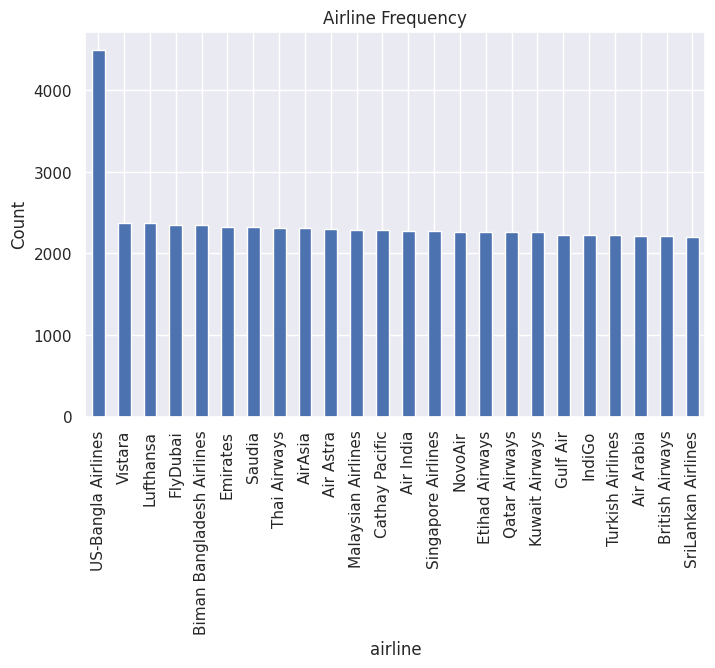

In [24]:
plt.figure(figsize=(8,5))
df['airline'].value_counts().plot(kind='bar')
plt.title("Airline Frequency")
plt.ylabel("Count")
plt.show()

Route Popularity

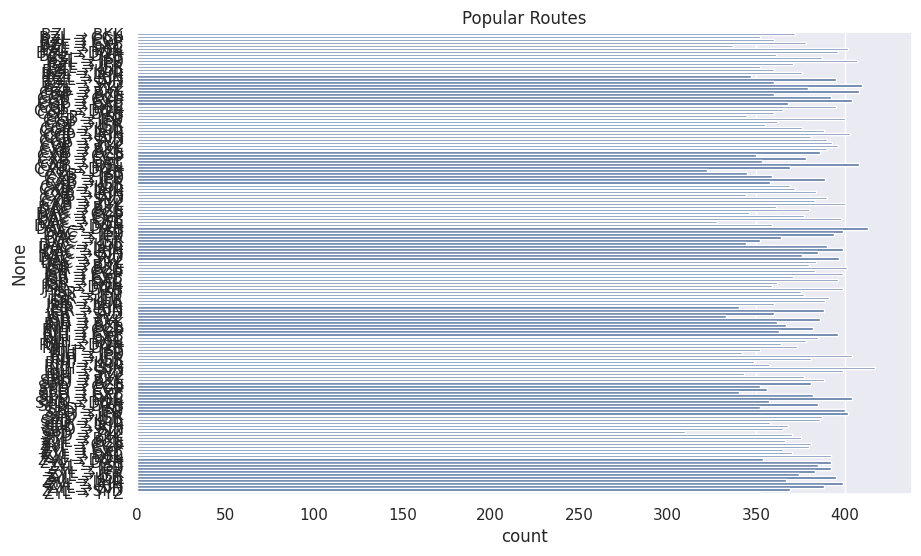

In [30]:
route_counts = df.groupby(['source', 'destination']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(x='count', y=route_counts['source'] + " → " + route_counts['destination'], data=route_counts)
plt.title("Popular Routes")
plt.show()